# Student Career Success - ML, DL & Salary Prediction Project

## Objective
Predict whether a student is **Not Placed / At Risk** or not using information that is available before placement.

**Target encoding**
- `0 = Placed`
- `1 = Not Placed / At Risk`

The notebook covers EDA, data quality, leakage detection, preprocessing, imbalance handling, Logistic Regression, KNN, SVM, Decision Tree, Random Forest, Naive Bayes, Bagging, AdaBoost, Gradient Boosting, XGBoost, PCA, cross-validation, tuning, feature importance, a TensorFlow/Keras neural network, final ML-vs-DL comparison, model saving, and Streamlit deployment.

After the placement classifier predicts **Placed**, a separate regression model estimates the student's expected `Starting_Salary_USD`.

The salary model is trained **only on students who were actually placed** and uses the same pre-placement features as the classifier. This keeps the two-stage deployment logically usable without requiring future outcome information.

## 0. Import libraries
```bash
pip install -r requirements.txt
```

In [59]:
import warnings, json, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report, mean_absolute_error, mean_squared_error, r2_score,
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from xgboost import XGBClassifier, XGBRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib

DATA_PATH = Path('student_career_success_dataset.csv')
pd.set_option('display.max_columns', 100)

## 1. Load and understand the data

In [2]:
df = pd.read_csv(DATA_PATH)
df

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,Projects_Completed,Certifications,Hackathons,GitHub_Profile,Internships,Leadership_Experience,LinkedIn_Profile,Resume_Score,Communication_Skills,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,10,1,6,Yes,5,No,No,100,9,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,6,0,5,Yes,2,No,Yes,80,5,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,9,0,5,Yes,3,Yes,No,100,7,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,6,3,3,No,2,No,Yes,85,6,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,10,1,2,Yes,3,Yes,Yes,100,10,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,ST049996,22,Male,Sophomore,Software Engineering,76,13,2.92,Average,9,7,4,3,Yes,4,No,No,100,8,5,8,Advanced,86,224.80,Placed,Tier 1,Software Engineer,Campus Placement,103525
49996,ST049997,21,Male,Senior,Artificial Intelligence,84,21,2.90,Average,7,7,2,3,No,2,Yes,Yes,99,7,9,7,Intermediate,69,190.70,Not Placed,No Company,Not Placed,Not Applicable,0
49997,ST049998,20,Female,Junior,Software Engineering,86,25,3.31,Good,9,10,1,4,Yes,5,Yes,Yes,100,10,6,9,Advanced,86,243.15,Placed,Tier 1,DevOps Engineer,Campus Placement,102324
49998,ST049999,20,Male,Junior,Software Engineering,92,15,3.05,Average,10,12,2,4,Yes,5,No,No,100,7,6,10,Advanced,87,245.25,Placed,Tier 1,DevOps Engineer,Referral,82095


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             50000 non-null  str    
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  str    
 3   University_Year        50000 non-null  str    
 4   Major                  50000 non-null  str    
 5   Attendance_Percentage  50000 non-null  int64  
 6   Study_Hours_Per_Week   50000 non-null  int64  
 7   CGPA                   50000 non-null  float64
 8   Academic_Performance   50000 non-null  str    
 9   Programming_Skill      50000 non-null  int64  
 10  Projects_Completed     50000 non-null  int64  
 11  Certifications         50000 non-null  int64  
 12  Hackathons             50000 non-null  int64  
 13  GitHub_Profile         50000 non-null  str    
 14  Internships            50000 non-null  int64  
 15  Leadership_Ex

## 2. Data quality

In [4]:
df.isna().sum()

Student_ID               0
Age                      0
Gender                   0
University_Year          0
Major                    0
Attendance_Percentage    0
Study_Hours_Per_Week     0
CGPA                     0
Academic_Performance     0
Programming_Skill        0
Projects_Completed       0
Certifications           0
Hackathons               0
GitHub_Profile           0
Internships              0
Leadership_Experience    0
LinkedIn_Profile         0
Resume_Score             0
Communication_Skills     0
Teamwork                 0
Problem_Solving          0
English_Proficiency      0
Interview_Score          0
Employability_Score      0
Placement_Status         0
Company_Tier             0
Career_Field             0
Placement_Mode           0
Starting_Salary_USD      0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,50000,50000,ST000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,50000.0,NaN,NaN,NaN,21.2629,2.041163,18.0,20.0,21.0,22.0,30.0
Gender,50000,3,Male,24533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
University_Year,50000,4,Junior,14870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Major,50000,8,Computer Science,12407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attendance_Percentage,50000.0,NaN,NaN,NaN,81.40964,9.709519,50.0,75.0,82.0,88.0,100.0
Study_Hours_Per_Week,50000.0,NaN,NaN,NaN,21.52816,6.97481,5.0,17.0,21.0,26.0,45.0
CGPA,50000.0,NaN,NaN,NaN,3.106043,0.290351,2.0,2.91,3.11,3.31,4.0
Academic_Performance,50000,4,Average,28890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Programming_Skill,50000.0,NaN,NaN,NaN,7.13716,1.507194,1.0,6.0,7.0,8.0,10.0


## 3. Target distribution

In [10]:
df['Placement_Status'].value_counts()

Placement_Status
Placed        39040
Not Placed    10960
Name: count, dtype: int64

In [11]:
df['Placement_Status'].value_counts(normalize=True).mul(100)

Placement_Status
Placed        78.08
Not Placed    21.92
Name: proportion, dtype: float64

### Initial review
- 50,000 rows, 29 columns
- 0 missing values
- 0 exact duplicate rows
- Target is moderately imbalanced: about 78% Placed and 22% Not Placed

So we will use a stratified split and focus on **Macro F1, at-risk Recall, and ROC-AUC**.

We use **Macro F1** not **F1** because it's the average of f1 score 
for both classes, and it treats minority & majority classes equally.

## 4. Target leakage check
These columns are post-placement outcomes and can reveal the target:
- `Company_Tier`
- `Career_Field`
- `Placement_Mode`
- `Starting_Salary_USD`

In [13]:
cols = ['Company_Tier','Career_Field','Placement_Mode','Starting_Salary_USD']
for col in cols:
    print(f'\n<=========== {col} ===========>')
    print(pd.crosstab(df[col], df['Placement_Status']))


<=========== Company_Tier ===========>
Placement_Status  Not Placed  Placed
Company_Tier                        
No Company             10960       0
Tier 1                     0   37152
Tier 2                     0    1751
Tier 3                     0     137

<=========== Career_Field ===========>
Placement_Status           Not Placed  Placed
Career_Field                                 
AI Engineer                         0    3792
Automation Engineer                 0     777
Backend Developer                   0    3352
Business Analyst                    0    1236
Cloud Engineer                      0    1717
Cybersecurity Analyst               0    1318
Data Analyst                        0    2749
Data Scientist                      0    3845
DevOps Engineer                     0    3214
Embedded Systems Engineer           0     757
Full Stack Developer                0    3198
IT Support Engineer                 0    1745
Machine Learning Engineer           0    2152
Not Plac

### Leakage decision
Remove before training:
- `Student_ID` — identifier only
- `Company_Tier` — known after placement
- `Career_Field` — known after placement
- `Placement_Mode` — known after placement
- `Starting_Salary_USD` — known after placement

## 5. Exploratory Data Analysis

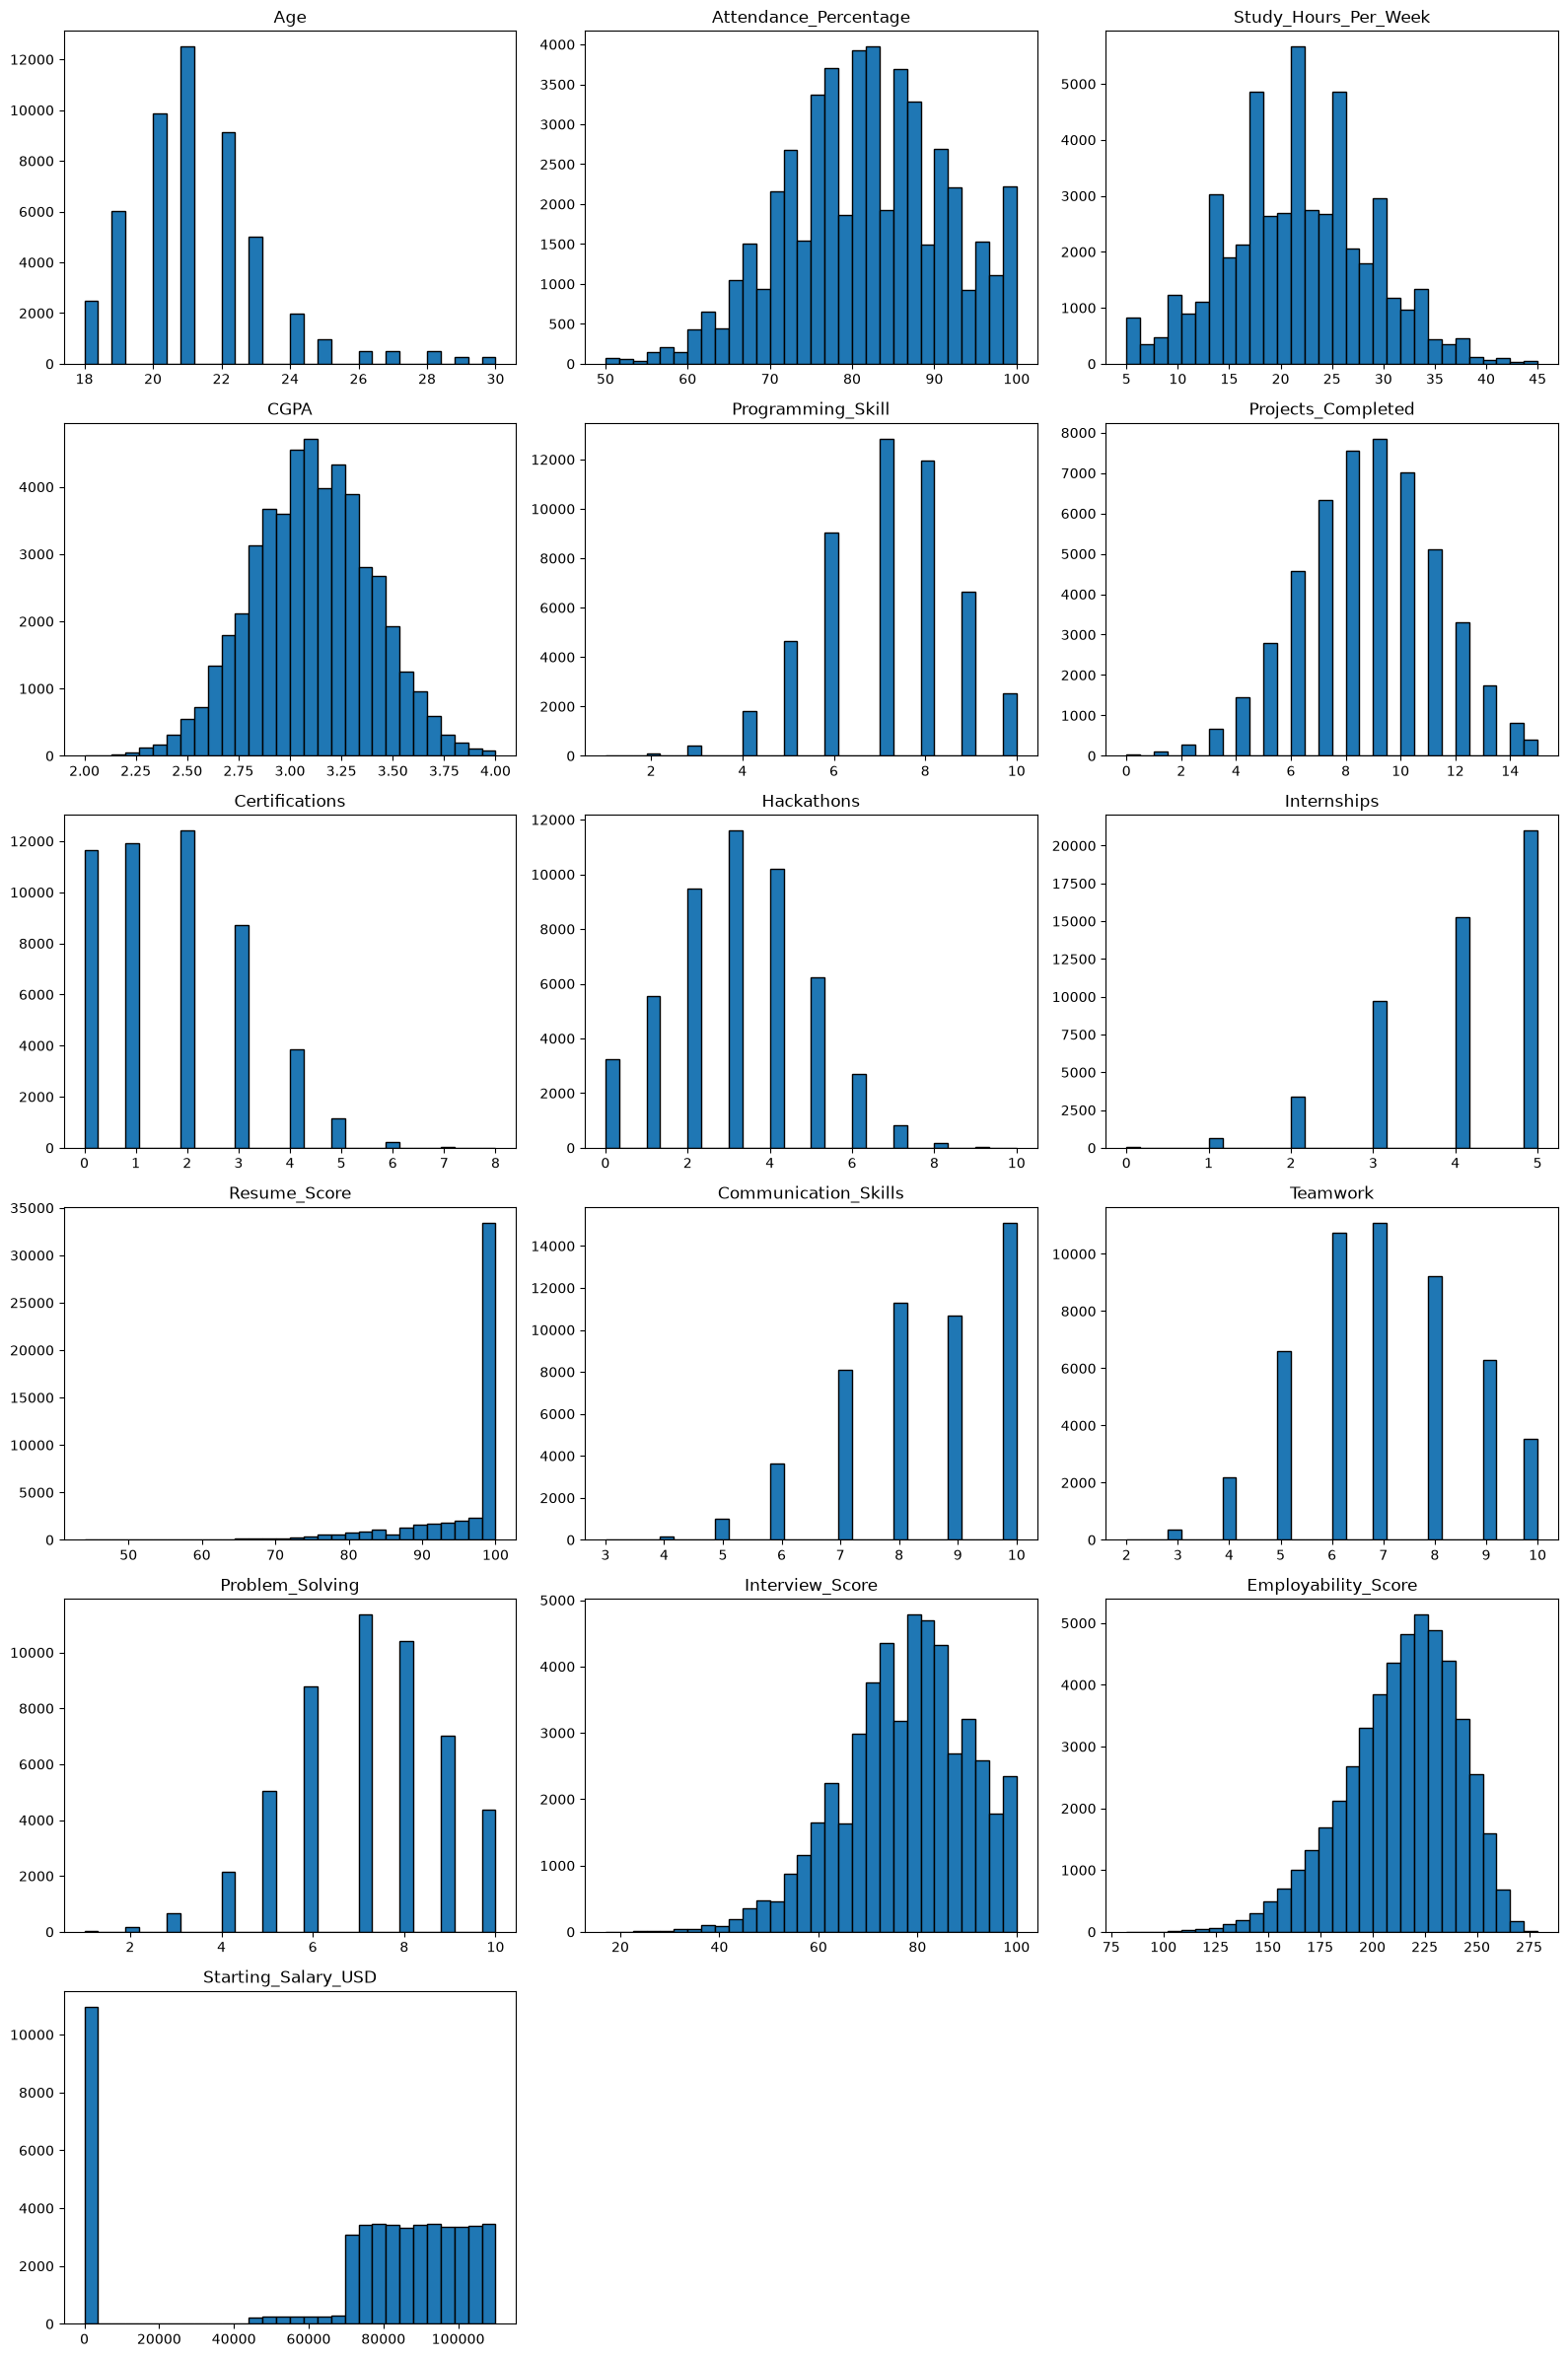

In [15]:
numeric_all = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(6, 3, figsize=(16, 24))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_all):
    ax.hist(df[col], bins=30, edgecolor='black')
    ax.set_title(col)

for ax in axes[len(numeric_all):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

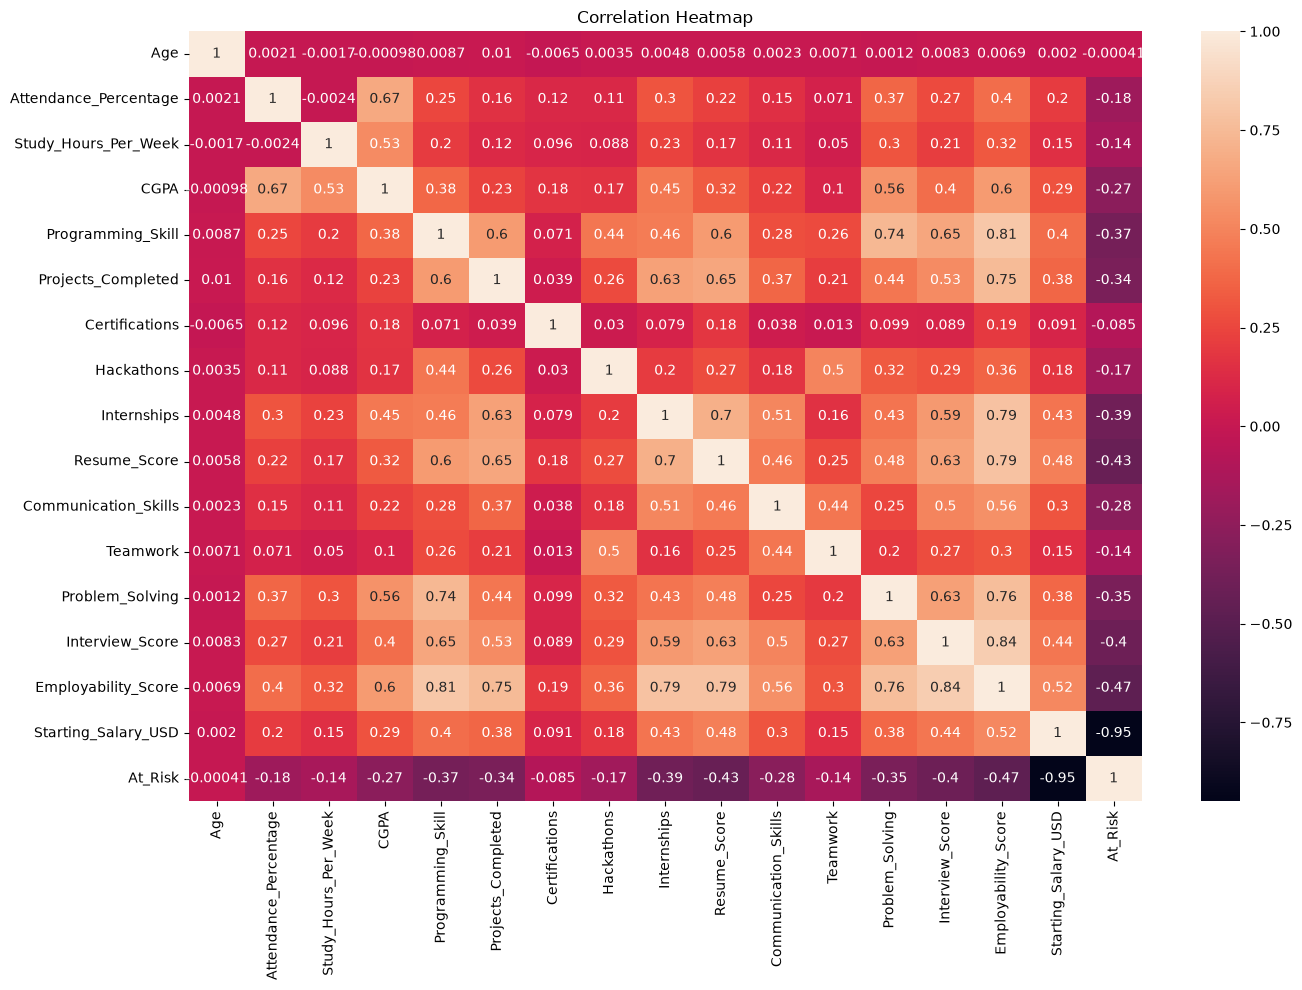

In [ ]:
df['At_Risk'] = (df['Placement_Status'] == 'Not Placed').astype(int)

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(correlation, annot=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [24]:
correlation['At_Risk'].drop('At_Risk').sort_values().to_frame('Correlation_with_At_Risk')

,Correlation_with_At_Risk
Starting_Salary_USD,-0.949921
Employability_Score,-0.472687
Resume_Score,-0.425195
Interview_Score,-0.402386
Internships,-0.392040
Programming_Skill,-0.370803
Problem_Solving,-0.348187
Projects_Completed,-0.344400
Communication_Skills,-0.275114
CGPA,-0.270335


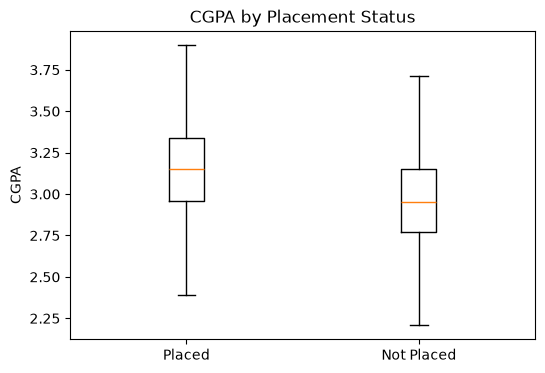

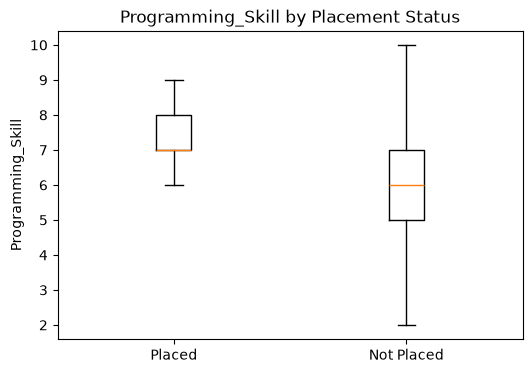

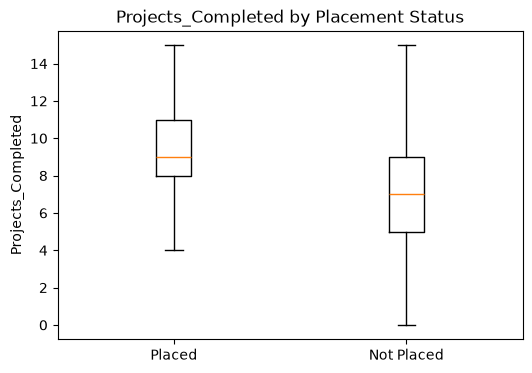

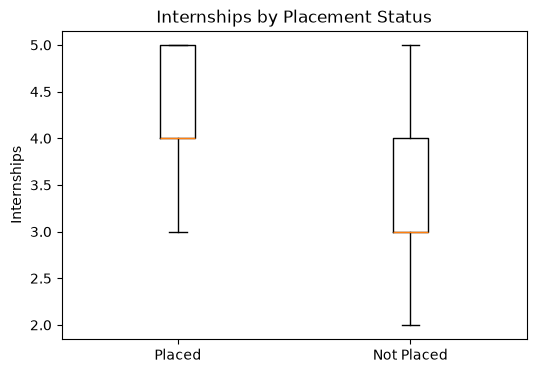

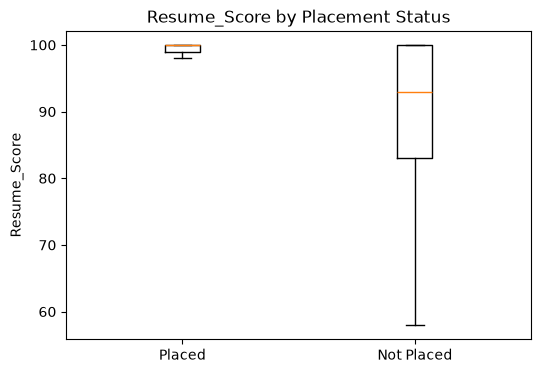

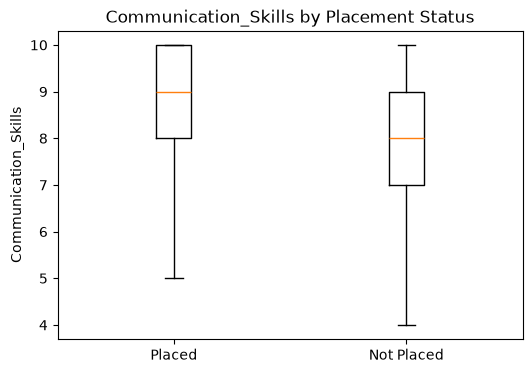

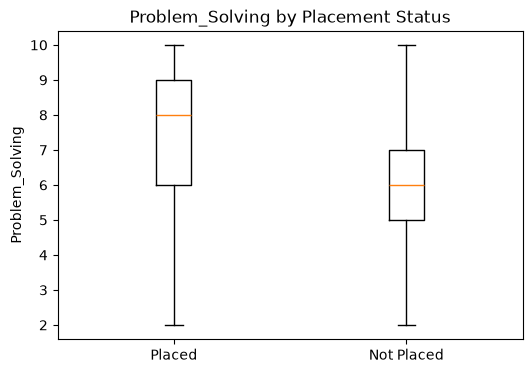

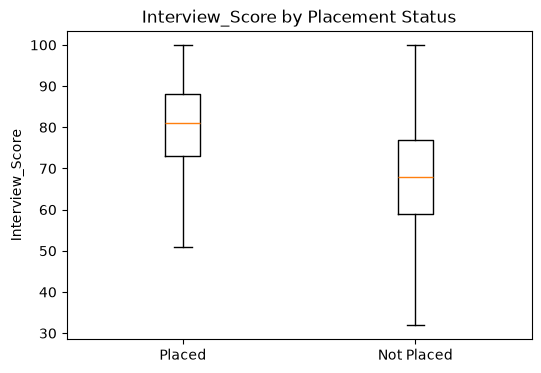

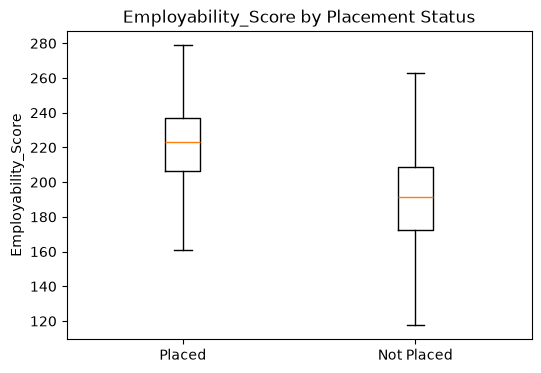

In [ ]:
cols = ['CGPA','Programming_Skill','Projects_Completed','Internships','Resume_Score',
        'Communication_Skills','Problem_Solving','Interview_Score','Employability_Score']

for col in cols:
    groups = [df.loc[df['Placement_Status']==s, col] for s in ['Placed','Not Placed']]
    plt.figure(figsize=(6,4))
    plt.boxplot(groups, tick_labels=['Placed','Not Placed'], showfliers=False)
    plt.title(f'{col} by Placement Status')
    plt.ylabel(col)
    plt.show()

## 6. Define features and target

In [29]:
df_training = df.copy()
df_training['Placement_Status'] = df_training['Placement_Status'].map({'Not Placed':1, 'Placed':0})
X_unwanted_cols = ['Student_ID','Placement_Status','Company_Tier','Career_Field','Placement_Mode','Starting_Salary_USD','At_Risk']
X = df_training.drop(columns=X_unwanted_cols)
y = df_training['Placement_Status']

In [30]:
X

,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,Projects_Completed,Certifications,Hackathons,GitHub_Profile,Internships,Leadership_Experience,LinkedIn_Profile,Resume_Score,Communication_Skills,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score
0,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,10,1,6,Yes,5,No,No,100,9,7,8,Advanced,72,231.70
1,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,6,0,5,Yes,2,No,Yes,80,5,6,5,Basic,59,157.45
2,23,Male,Senior,Information Technology,75,19,2.83,Average,8,9,0,5,Yes,3,Yes,No,100,7,8,7,Advanced,76,203.45
3,23,Female,Senior,Information Technology,80,19,2.80,Average,5,6,3,3,No,2,No,Yes,85,6,6,6,Intermediate,67,171.50
4,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,10,1,2,Yes,3,Yes,Yes,100,10,8,9,Advanced,82,225.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,22,Male,Sophomore,Software Engineering,76,13,2.92,Average,9,7,4,3,Yes,4,No,No,100,8,5,8,Advanced,86,224.80
49996,21,Male,Senior,Artificial Intelligence,84,21,2.90,Average,7,7,2,3,No,2,Yes,Yes,99,7,9,7,Intermediate,69,190.70
49997,20,Female,Junior,Software Engineering,86,25,3.31,Good,9,10,1,4,Yes,5,Yes,Yes,100,10,6,9,Advanced,86,243.15
49998,20,Male,Junior,Software Engineering,92,15,3.05,Average,10,12,2,4,Yes,5,No,No,100,7,6,10,Advanced,87,245.25


In [31]:
y

0        0
1        1
2        0
3        1
4        0
        ..
49995    0
49996    1
49997    0
49998    0
49999    0
Name: Placement_Status, Length: 50000, dtype: int64

## 7. Split BEFORE fitting preprocessing

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(40000, 23) (10000, 23)


## 8. Preprocessing
Ordinal encoding for naturally ordered categories, one-hot encoding for nominal categories, and scaling for numeric values.

In [33]:
ordinal_columns = ['University_Year','Academic_Performance','English_Proficiency']
nominal_columns = ['Gender','Major','GitHub_Profile','Leadership_Experience','LinkedIn_Profile']
numeric_columns = [c for c in X.columns if c not in ordinal_columns + nominal_columns]

numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[
            ['Freshman','Sophomore','Junior','Senior'],
            ['Poor','Average','Good','Excellent'],
            ['Basic','Intermediate','Advanced']
        ], handle_unknown='use_encoded_value', unknown_value=-1)),
    ('scaler', StandardScaler())
])
nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_columns),
    ('ord', ordinal_pipe, ordinal_columns),
    ('nom', nominal_pipe, nominal_columns)
])

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print('Before:', X_train.shape, 'After:', X_train_p.shape)

Before: (40000, 23) After: (40000, 35)


## 9. Evaluation metrics
Primary metric: **Macro F1**. It gives equal importance to Placed and Not Placed.

We also report at-risk Precision/Recall/F1, Weighted F1, ROC-AUC, and Accuracy.

In [34]:
def scores_for(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        score = model.predict_proba(X_eval)[:,1]
    elif hasattr(model, 'decision_function'):
        score = model.decision_function(X_eval)
    else:
        score = None
    return {
        'Accuracy': accuracy_score(y_eval,pred),
        'Precision_At_Risk': precision_score(y_eval,pred,zero_division=0),
        'Recall_At_Risk': recall_score(y_eval,pred,zero_division=0),
        'F1_At_Risk': f1_score(y_eval,pred,zero_division=0),
        'F1_Macro': f1_score(y_eval,pred,average='macro',zero_division=0),
        'F1_Weighted': f1_score(y_eval,pred,average='weighted',zero_division=0),
        'ROC_AUC': roc_auc_score(y_eval,score) if score is not None else np.nan
    }

def fit_and_score(name, model):
    t = time.time(); model.fit(X_train_p,y_train)
    row = scores_for(model,X_test_p,y_test)
    row.update({'Model':name,'Train_Time_sec':time.time()-t})
    return row, model

## 10. Classical ML models + Bagging/Boosting

In [35]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000,class_weight='balanced',random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Linear SVM': LinearSVC(class_weight='balanced',random_state=42,max_iter=10000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced',random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=42,n_jobs=-1),
    'Gaussian Naive Bayes': GaussianNB(),
    'Bagging': BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),n_estimators=75,random_state=42,n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=150,learning_rate=0.7,random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150,random_state=42)
}
results=[]; trained_models={}
for name, model in models.items():
    print('Training:', name)
    row, fitted = fit_and_score(name, model)
    results.append(row); trained_models[name]=fitted
results_df = pd.DataFrame(results).sort_values('F1_Macro',ascending=False).reset_index(drop=True)
display(results_df)

Training: Logistic Regression
Training: KNN
Training: Linear SVM
Training: Decision Tree
Training: Random Forest
Training: Gaussian Naive Bayes
Training: Bagging
Training: AdaBoost
Training: Gradient Boosting


,Accuracy,Precision_At_Risk,Recall_At_Risk,F1_At_Risk,F1_Macro,F1_Weighted,ROC_AUC,Model,Train_Time_sec
0,0.7991,0.538821,0.579380,0.558364,0.714170,0.801671,0.809742,Random Forest,2.527730
1,0.7724,0.485366,0.635493,0.550375,0.699006,0.782477,0.794162,Gaussian Naive Bayes,0.080540
2,0.7452,0.448644,0.709398,0.549664,0.686002,0.762569,0.809449,Linear SVM,0.237971
3,0.7441,0.447316,0.710766,0.549075,0.685218,0.761676,0.809484,Logistic Regression,0.147081
4,0.8211,0.671489,0.359945,0.468666,0.680555,0.799551,0.810320,AdaBoost,7.182568
5,0.8203,0.668085,0.358120,0.466290,0.679126,0.798655,0.809724,Gradient Boosting,15.214757
6,0.8096,0.614105,0.353558,0.448755,0.666841,0.789318,0.801671,Bagging,12.660900
7,0.7996,0.569424,0.351734,0.434856,0.656531,0.781024,0.749269,KNN,1.420317
8,0.7443,0.414759,0.405109,0.409878,0.623334,0.743211,0.622317,Decision Tree,0.674528


## 11. XGBoost

In [37]:
pos_weight = (y_train==0).sum()/(y_train==1).sum()
xgb = XGBClassifier(n_estimators=350,max_depth=4,learning_rate=0.05,
                    subsample=0.9,colsample_bytree=0.9,scale_pos_weight=pos_weight,
                    eval_metric='logloss',random_state=42,n_jobs=-1)
row, fitted = fit_and_score('XGBoost', xgb)
trained_models['XGBoost']=fitted
results_df = pd.concat([results_df,pd.DataFrame([row])],ignore_index=True).sort_values('F1_Macro',ascending=False).reset_index(drop=True)
display(results_df)

,Accuracy,Precision_At_Risk,Recall_At_Risk,F1_At_Risk,F1_Macro,F1_Weighted,ROC_AUC,Model,Train_Time_sec
0,0.7991,0.538821,0.579380,0.558364,0.714170,0.801671,0.809742,Random Forest,2.527730
1,0.7724,0.485366,0.635493,0.550375,0.699006,0.782477,0.794162,Gaussian Naive Bayes,0.080540
2,0.7596,0.467445,0.694343,0.558737,0.696768,0.774287,0.808058,XGBoost,1.043777
3,0.7452,0.448644,0.709398,0.549664,0.686002,0.762569,0.809449,Linear SVM,0.237971
4,0.7441,0.447316,0.710766,0.549075,0.685218,0.761676,0.809484,Logistic Regression,0.147081
5,0.8211,0.671489,0.359945,0.468666,0.680555,0.799551,0.810320,AdaBoost,7.182568
6,0.8203,0.668085,0.358120,0.466290,0.679126,0.798655,0.809724,Gradient Boosting,15.214757
7,0.8096,0.614105,0.353558,0.448755,0.666841,0.789318,0.801671,Bagging,12.660900
8,0.7996,0.569424,0.351734,0.434856,0.656531,0.781024,0.749269,KNN,1.420317
9,0.7443,0.414759,0.405109,0.409878,0.623334,0.743211,0.622317,Decision Tree,0.674528


## 12. Compare ML models

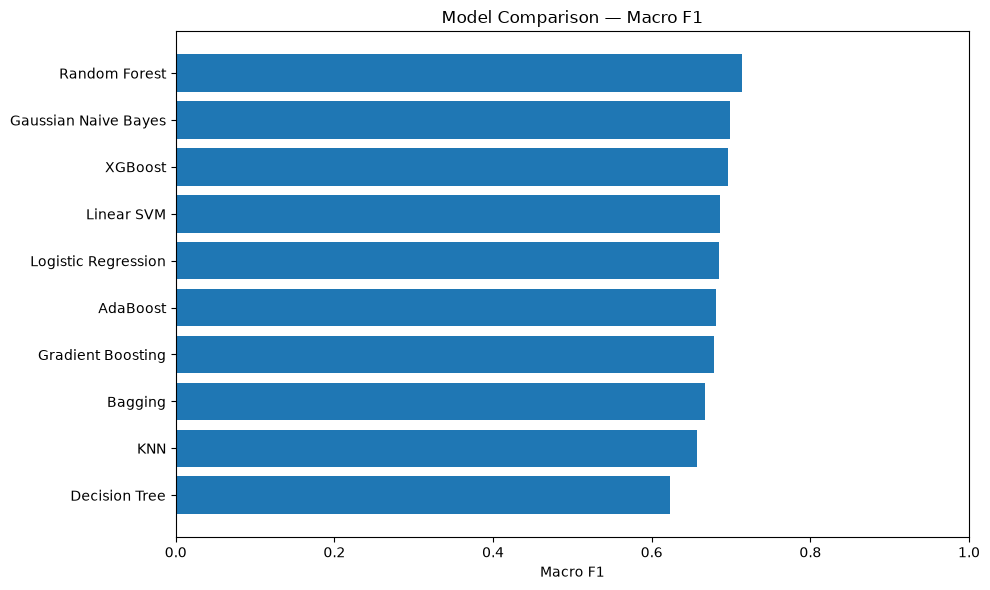

In [38]:
plot_df = results_df.sort_values('F1_Macro')
plt.figure(figsize=(10,6))
plt.barh(plot_df['Model'],plot_df['F1_Macro'])
plt.xlim(0,1)
plt.title('Model Comparison — Macro F1')
plt.xlabel('Macro F1')
plt.tight_layout()
plt.show()

Best baseline ML model: Random Forest
              precision    recall  f1-score   support

      Placed       0.88      0.86      0.87      7808
  Not Placed       0.54      0.58      0.56      2192

    accuracy                           0.80     10000
   macro avg       0.71      0.72      0.71     10000
weighted avg       0.80      0.80      0.80     10000



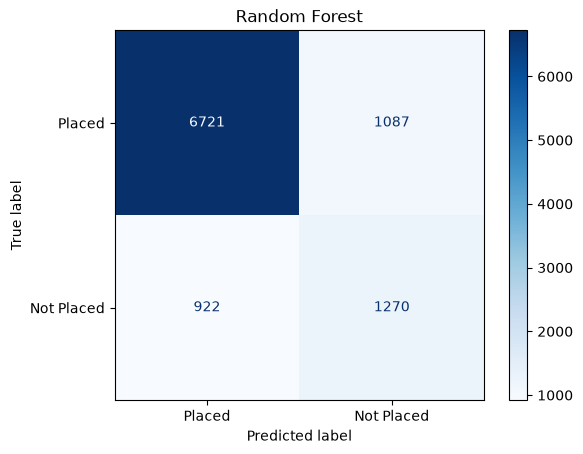

In [39]:
best_ml_name = results_df.iloc[0]['Model']
best_ml = trained_models[best_ml_name]
print('Best baseline ML model:', best_ml_name)
print(classification_report(y_test,best_ml.predict(X_test_p),target_names=['Placed','Not Placed']))
ConfusionMatrixDisplay.from_predictions(y_test,best_ml.predict(X_test_p),display_labels=['Placed','Not Placed'],cmap='Blues')
plt.title(best_ml_name)
plt.show()

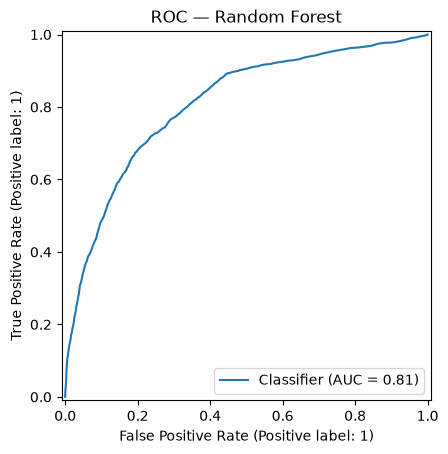

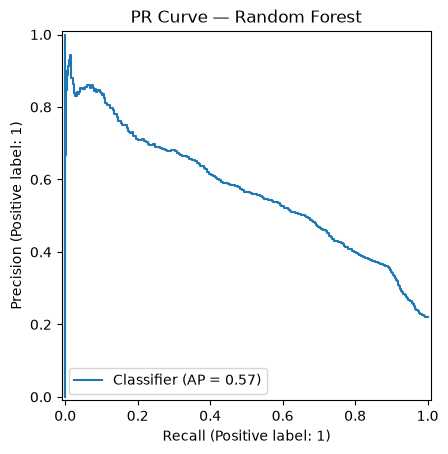

In [40]:
if hasattr(best_ml,'predict_proba'):
    s=best_ml.predict_proba(X_test_p)[:,1]
elif hasattr(best_ml,'decision_function'):
    s=best_ml.decision_function(X_test_p)
else: s=None
if s is not None:
    RocCurveDisplay.from_predictions(y_test,s)
    plt.title(f'ROC — {best_ml_name}')
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test,s)
    plt.title(f'PR Curve — {best_ml_name}')
    plt.show()

## 13. Cross-validation
Preprocessing is refit inside every fold using a Pipeline, avoiding CV leakage.

In [41]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_rows=[]
for name in results_df['Model'].head(3):
    pipe=Pipeline([('preprocessor',clone(preprocessor)),('model',clone(trained_models[name]))])
    sc=cross_validate(pipe,X_train,y_train,cv=cv,scoring={'acc':'accuracy','f1m':'f1_macro','auc':'roc_auc'},n_jobs=-1)
    cv_rows.append({'Model':name,'CV_Accuracy':sc['test_acc'].mean(),'CV_F1_Macro':sc['test_f1m'].mean(),
                    'CV_F1_Macro_STD':sc['test_f1m'].std(),'CV_ROC_AUC':sc['test_auc'].mean()})
cv_results=pd.DataFrame(cv_rows).sort_values('CV_F1_Macro',ascending=False)
display(cv_results)

,Model,CV_Accuracy,CV_F1_Macro,CV_F1_Macro_STD,CV_ROC_AUC
0,Random Forest,0.796925,0.711869,0.005930,0.808542
1,Gaussian Naive Bayes,0.770950,0.696119,0.003551,0.796779
2,XGBoost,0.755250,0.694015,0.002927,0.809827


## 14. Hyperparameter tuning

In [ ]:
tuned_pipelines={}; tuned_rows=[]
searches={
 'Logistic Regression Tuned': (LogisticRegression(max_iter=3000,random_state=42), {'model__C':[0.05,0.1,0.5,1,2,5],'model__class_weight':[None,'balanced']}),
 'Gaussian NB Tuned': (GaussianNB(),{'model__var_smoothing':np.logspace(-11,-7,7)}),
 'Random Forest Tuned': (RandomForestClassifier(random_state=42,n_jobs=-1), {'model__n_estimators':[200,350],'model__max_depth':[None,10,20],
                                                                             'model__min_samples_leaf':[1,2,5],'model__class_weight':['balanced','balanced_subsample']})
}

for name,(est,grid) in searches.items():
    print('Tuning:',name)
    pipe=Pipeline([('preprocessor',clone(preprocessor)),('model',est)])
    gs=GridSearchCV(pipe,grid,scoring='f1_macro',cv=3,n_jobs=-1)
    gs.fit(X_train,y_train)
    pred=gs.predict(X_test)

    if hasattr(gs,'predict_proba'): score=gs.predict_proba(X_test)[:,1]
    elif hasattr(gs,'decision_function'): score=gs.decision_function(X_test)
    else: score=None

    tuned_rows.append({'Model':name,'Accuracy':accuracy_score(y_test,pred),
                       'Precision_At_Risk':precision_score(y_test,pred,zero_division=0),
                       'Recall_At_Risk':recall_score(y_test,pred,zero_division=0),
                       'F1_At_Risk':f1_score(y_test,pred,zero_division=0),
                       'F1_Macro':f1_score(y_test,pred,average='macro'),
                       'F1_Weighted':f1_score(y_test,pred,average='weighted'),
                       'ROC_AUC':roc_auc_score(y_test,score) if score is not None else np.nan,
                       'Best_Params':gs.best_params_})
    tuned_pipelines[name]=gs.best_estimator_

tuned_results_df=pd.DataFrame(tuned_rows).sort_values('F1_Macro',ascending=False)
display(tuned_results_df)

Tuning: Logistic Regression Tuned
Tuning: Gaussian NB Tuned
Tuning: Random Forest Tuned


,Model,Accuracy,Precision_At_Risk,Recall_At_Risk,F1_At_Risk,F1_Macro,F1_Weighted,ROC_AUC,Best_Params
2,Random Forest Tuned,0.7924,0.521772,0.634124,0.572488,0.717702,0.799254,0.810745,"{'model__class_weight': 'balanced_subsample', ..."
1,Gaussian NB Tuned,0.7724,0.485366,0.635493,0.550375,0.699006,0.782477,0.794162,{'model__var_smoothing': 1e-11}
0,Logistic Regression Tuned,0.7440,0.447187,0.710766,0.548978,0.685129,0.761591,0.809484,"{'model__C': 0.05, 'model__class_weight': 'bal..."


## 15. PCA experiment

In [43]:
pca_pipeline=Pipeline([
 ('preprocessor',clone(preprocessor)),('pca',PCA(n_components=0.95,random_state=42)),
 ('model',LogisticRegression(max_iter=2000,class_weight='balanced',random_state=42))])

pca_pipeline.fit(X_train,y_train)

pred=pca_pipeline.predict(X_test)
prob=pca_pipeline.predict_proba(X_test)[:,1]

pca_row={'Model':'Logistic Regression + PCA','Accuracy':accuracy_score(y_test,pred),
         'Precision_At_Risk':precision_score(y_test,pred),'Recall_At_Risk':recall_score(y_test,pred),
         'F1_At_Risk':f1_score(y_test,pred),'F1_Macro':f1_score(y_test,pred,average='macro'),
         'F1_Weighted':f1_score(y_test,pred,average='weighted'),'ROC_AUC':roc_auc_score(y_test,prob)
}

display(pd.DataFrame([pca_row]))
print('PCA components retained:',pca_pipeline.named_steps['pca'].n_components_)

,Model,Accuracy,Precision_At_Risk,Recall_At_Risk,F1_At_Risk,F1_Macro,F1_Weighted,ROC_AUC
0,Logistic Regression + PCA,0.7443,0.447361,0.707573,0.548153,0.684927,0.761739,0.80916


PCA components retained: 19


## 16. Feature importance

,Feature,Importance
14,num__Employability_Score,0.173992
13,num__Interview_Score,0.086975
3,num__CGPA,0.066232
9,num__Resume_Score,0.059079
1,num__Attendance_Percentage,0.056492
2,num__Study_Hours_Per_Week,0.053425
5,num__Projects_Completed,0.050243
4,num__Programming_Skill,0.045961
12,num__Problem_Solving,0.044678
8,num__Internships,0.041289


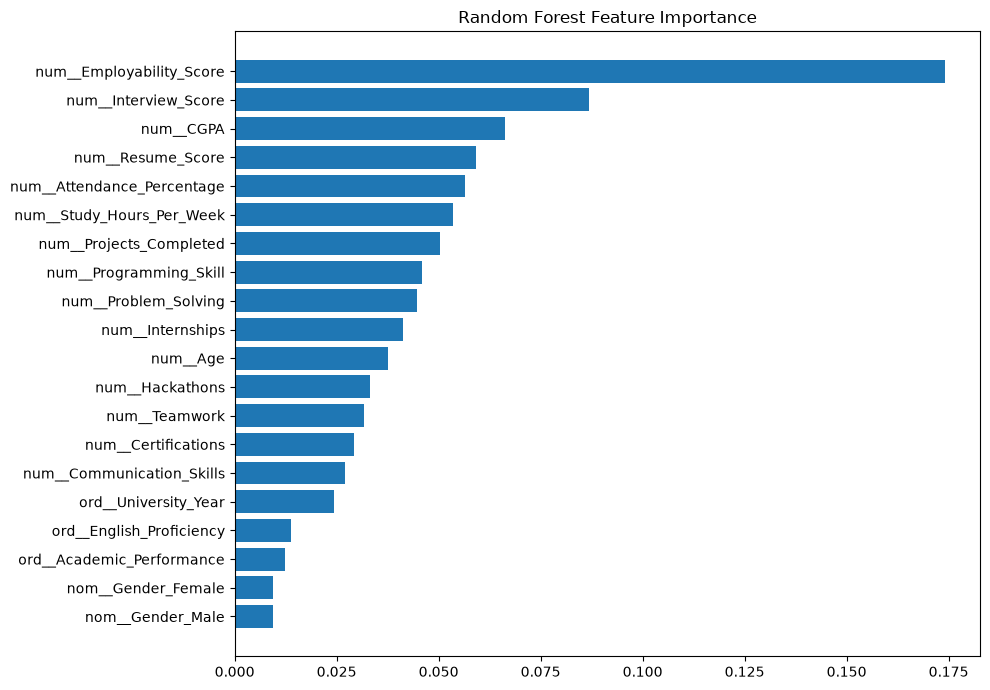

In [44]:
if 'Random Forest' in trained_models:
    imp=pd.DataFrame({'Feature':feature_names,'Importance':trained_models['Random Forest'].feature_importances_}).sort_values('Importance',ascending=False)
    display(imp.head(20))
    top=imp.head(20).sort_values('Importance')

    plt.figure(figsize=(10,7))
    plt.barh(top['Feature'],top['Importance'])
    plt.title('Random Forest Feature Importance')
    plt.tight_layout()
    plt.show()

# Part II - Deep Learning
## 17. TensorFlow/Keras dense neural network

In [46]:
tf.random.set_seed(42)
np.random.seed(42)
classes=np.array([0,1])
cw=compute_class_weight(class_weight='balanced',classes=classes,y=y_train)
class_weights={0:float(cw[0]),1:float(cw[1])}

nn_model=keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(64,activation='relu'),layers.BatchNormalization(),layers.Dropout(0.25),
    layers.Dense(32,activation='relu'),layers.Dropout(0.20),
    layers.Dense(16,activation='relu'),layers.Dense(1,activation='sigmoid')])

In [48]:
nn_model.compile(optimizer=keras.optimizers.Adam(1e-3),loss='binary_crossentropy',
                 metrics=['accuracy',keras.metrics.AUC(name='auc'),keras.metrics.Precision(name='precision'),keras.metrics.Recall(name='recall')])

callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True),
           keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-6)]

history=nn_model.fit(X_train_p,y_train,validation_split=0.15,epochs=40,batch_size=256,
                     class_weight=class_weights,callbacks=callbacks,verbose=1)

Epoch 1/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7349 - auc: 0.7976 - loss: 0.5513 - precision: 0.4378 - recall: 0.7251 - val_accuracy: 0.7335 - val_auc: 0.8052 - val_loss: 0.5448 - val_precision: 0.4321 - val_recall: 0.7475 - learning_rate: 0.0010
Epoch 2/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7343 - auc: 0.8027 - loss: 0.5437 - precision: 0.4382 - recall: 0.7405 - val_accuracy: 0.7207 - val_auc: 0.8065 - val_loss: 0.5509 - val_precision: 0.4190 - val_recall: 0.7614 - learning_rate: 0.0010
Epoch 3/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7329 - auc: 0.8039 - loss: 0.5418 - precision: 0.4370 - recall: 0.7463 - val_accuracy: 0.7217 - val_auc: 0.8070 - val_loss: 0.5482 - val_precision: 0.4202 - val_recall: 0.7629 - learning_rate: 0.0010
Epoch 4/40
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7296 - auc: 0.8051 - loss: 0.5393 - precision: 0.4336 - recall: 0.7524 - val_accuracy: 0.7150 - val_auc: 0.8061 - val_loss: 0.5609 - val

## 18. Neural network learning curves and evaluation

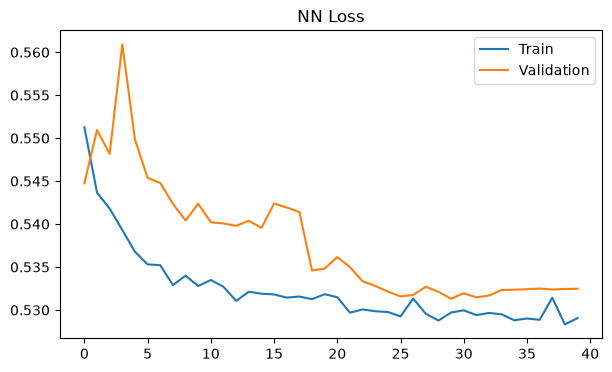

In [49]:
h=pd.DataFrame(history.history)
plt.figure(figsize=(7,4))
plt.plot(h['loss'],label='Train')
plt.plot(h['val_loss'],label='Validation')
plt.title('NN Loss')
plt.legend()
plt.show()

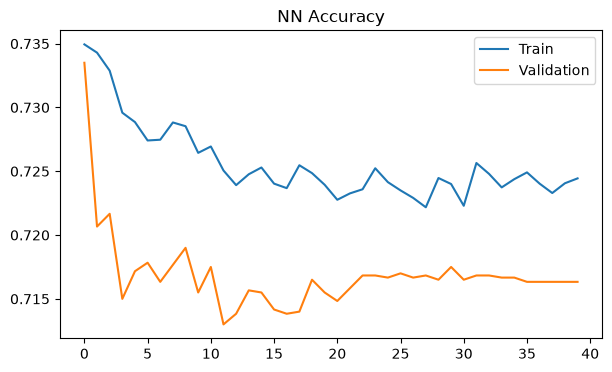

In [50]:
plt.figure(figsize=(7,4))
plt.plot(h['accuracy'],label='Train')
plt.plot(h['val_accuracy'],label='Validation')
plt.title('NN Accuracy')
plt.legend()
plt.show()

,Model,Accuracy,Precision_At_Risk,Recall_At_Risk,F1_At_Risk,F1_Macro,F1_Weighted,ROC_AUC
0,Neural Network,0.7123,0.414053,0.752737,0.53424,0.663054,0.735396,0.807315


              precision    recall  f1-score   support

      Placed       0.91      0.70      0.79      7808
  Not Placed       0.41      0.75      0.53      2192

    accuracy                           0.71     10000
   macro avg       0.66      0.73      0.66     10000
weighted avg       0.80      0.71      0.74     10000



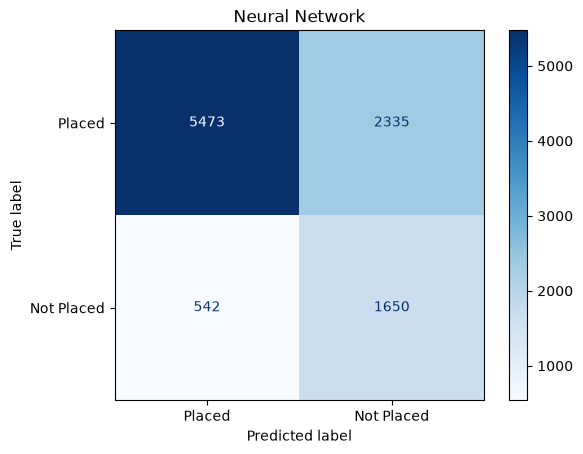

In [51]:
prob=nn_model.predict(X_test_p,verbose=0).ravel()
pred=(prob>=0.5).astype(int)

nn_row={'Model':'Neural Network','Accuracy':accuracy_score(y_test,pred),
        'Precision_At_Risk':precision_score(y_test,pred,zero_division=0),'Recall_At_Risk':recall_score(y_test,pred,zero_division=0),
        'F1_At_Risk':f1_score(y_test,pred,zero_division=0),'F1_Macro':f1_score(y_test,pred,average='macro'),
        'F1_Weighted':f1_score(y_test,pred,average='weighted'),'ROC_AUC':roc_auc_score(y_test,prob)}

display(pd.DataFrame([nn_row])); print(classification_report(y_test,pred,target_names=['Placed','Not Placed']))
ConfusionMatrixDisplay.from_predictions(y_test,pred,display_labels=['Placed','Not Placed'],cmap='Blues')
plt.title('Neural Network')
plt.show()

# Part III - Final ML vs DL comparison

In [53]:
frames=[results_df.copy()]
if 'tuned_results_df' in globals(): 
    frames.append(tuned_results_df.drop(columns=['Best_Params'],errors='ignore'))

frames.append(pd.DataFrame([pca_row]))
if nn_row is not None: 
    frames.append(pd.DataFrame([nn_row]))
final_comparison=pd.concat(frames,ignore_index=True).drop_duplicates('Model',keep='last').sort_values('F1_Macro',ascending=False).reset_index(drop=True)
display(final_comparison)

,Accuracy,Precision_At_Risk,Recall_At_Risk,F1_At_Risk,F1_Macro,F1_Weighted,ROC_AUC,Model,Train_Time_sec
0,0.7924,0.521772,0.634124,0.572488,0.717702,0.799254,0.810745,Random Forest Tuned,NaN
1,0.7991,0.538821,0.579380,0.558364,0.714170,0.801671,0.809742,Random Forest,2.527730
2,0.7724,0.485366,0.635493,0.550375,0.699006,0.782477,0.794162,Gaussian Naive Bayes,0.080540
3,0.7724,0.485366,0.635493,0.550375,0.699006,0.782477,0.794162,Gaussian NB Tuned,NaN
4,0.7596,0.467445,0.694343,0.558737,0.696768,0.774287,0.808058,XGBoost,1.043777
5,0.7452,0.448644,0.709398,0.549664,0.686002,0.762569,0.809449,Linear SVM,0.237971
6,0.7441,0.447316,0.710766,0.549075,0.685218,0.761676,0.809484,Logistic Regression,0.147081
7,0.7440,0.447187,0.710766,0.548978,0.685129,0.761591,0.809484,Logistic Regression Tuned,NaN
8,0.7443,0.447361,0.707573,0.548153,0.684927,0.761739,0.809160,Logistic Regression + PCA,NaN
9,0.8211,0.671489,0.359945,0.468666,0.680555,0.799551,0.810320,AdaBoost,7.182568


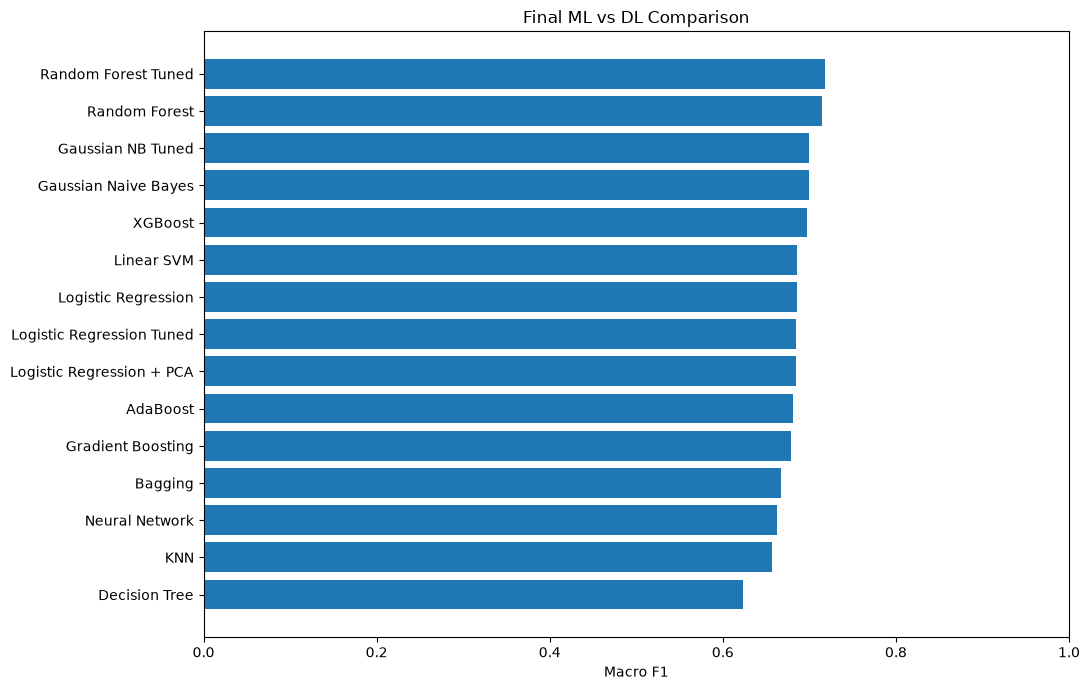

In [54]:
plt.figure(figsize=(11,7))
p=final_comparison.sort_values('F1_Macro')
plt.barh(p['Model'],p['F1_Macro'])
plt.xlim(0,1)
plt.title('Final ML vs DL Comparison')
plt.xlabel('Macro F1')
plt.tight_layout()
plt.show()


In [55]:
best=final_comparison.iloc[0]
print('BEST MODEL BY MACRO F1:',best['Model'])
print(best)
final_comparison.to_csv('model_comparison_results.csv',index=False)

BEST MODEL BY MACRO F1: Random Forest Tuned
Accuracy                          0.7924
Precision_At_Risk               0.521772
Recall_At_Risk                  0.634124
F1_At_Risk                      0.572488
F1_Macro                        0.717702
F1_Weighted                     0.799254
ROC_AUC                         0.810745
Model                Random Forest Tuned
Train_Time_sec                       NaN
Name: 0, dtype: object


# Part IV - Starting Salary Regression

### Important data decision
`Starting_Salary_USD = 0` for `Not Placed` students does **not** mean a real zero-dollar salary. It means that no starting salary exists. Therefore, the salary model must be trained **only on rows where `Placement_Status == "Placed"`**.

We also exclude `Company_Tier`, `Career_Field`, and `Placement_Mode` from the deployed salary model. Although they can be related to salary, they describe the placement outcome and are not guaranteed to be known when the two-stage system makes its prediction. This keeps the prediction based on the same pre-placement student information used by the classifier.

## 19. Prepare the placed-student regression dataset

In [60]:
placed_df = df[df['Placement_Status'] == 'Placed'].copy()
X_unwanted_cols = ['Student_ID','Placement_Status','Starting_Salary_USD','Company_Tier','Career_Field','Placement_Mode']
X_salary = placed_df.drop(columns=X_unwanted_cols)
y_salary = placed_df['Starting_Salary_USD']

print('Placed students used for salary regression:', len(placed_df))
print('Salary range:')
display(y_salary.describe().to_frame('Starting_Salary_USD'))

Placed students used for salary regression: 39040
Salary range:


,Starting_Salary_USD
count,39040.000000
mean,88355.747285
std,13608.503361
min,25096.000000
25%,78501.750000
50%,89025.000000
75%,99531.000000
max,110000.000000


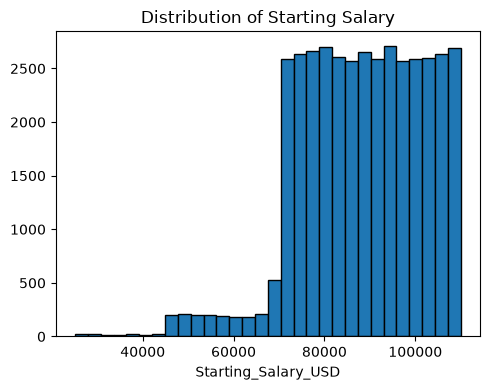

In [70]:
plt.figure(figsize=(5, 4))
plt.hist(placed_df['Starting_Salary_USD'], bins=30, edgecolor='black')
plt.title("Distribution of Starting Salary")
plt.xlabel('Starting_Salary_USD')
plt.tight_layout()
plt.show()

## 20. Salary train/test split

We split the placed-student data independently from the classification split.

In [61]:
X_salary_train, X_salary_test, y_salary_train, y_salary_test = train_test_split(X_salary, y_salary, test_size=0.20,random_state=42)

print('Salary train shape:', X_salary_train.shape)
print('Salary test shape:', X_salary_test.shape)

Salary train shape: (31232, 24)
Salary test shape: (7808, 24)


## 21. Salary preprocessing

The salary regression model uses the **same feature types** as the placement classifier, so we use it.

In [62]:
salary_preprocessor = clone(preprocessor)

X_salary_train_processed = salary_preprocessor.fit_transform(X_salary_train)
X_salary_test_processed = salary_preprocessor.transform(X_salary_test)

print('Before preprocessing:', X_salary_train.shape)
print('After preprocessing:', X_salary_train_processed.shape)

Before preprocessing: (31232, 24)
After preprocessing: (31232, 35)


## 22. Regression metrics

For salary prediction we use **MAE**, **RMSE**, and **R²**.

For deployment, we select the model with the **lowest MAE**, because it has the easiest real-world interpretation: approximately how many dollars off the prediction is on average.

In [63]:
def evaluate_regressor(name, model, X_tr, y_tr, X_te, y_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    return {
        'Model': name,
        'MAE': mean_absolute_error(y_te, pred),
        'RMSE': mean_squared_error(y_te, pred) ** 0.5,
        'R2': r2_score(y_te, pred),
        'Train_Time_sec': time.time() - start
    }, model, pred

## 23. Compare salary regression models

In [64]:
salary_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10.0),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42, min_samples_leaf=5),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=200, min_samples_leaf=2, max_features=0.8, random_state=42, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42)
}

salary_results = []
trained_salary_models = {}
salary_predictions = {}

for name, model in salary_models.items():
    print('Training salary model:', name)
    row, fitted, pred = evaluate_regressor(
        name,
        model,
        X_salary_train_processed,
        y_salary_train,
        X_salary_test_processed,
        y_salary_test
    )
    salary_results.append(row)
    trained_salary_models[name] = fitted
    salary_predictions[name] = pred

salary_results_df = (
    pd.DataFrame(salary_results)
    .sort_values('MAE')
    .reset_index(drop=True)
)

display(salary_results_df)

Training salary model: Linear Regression
Training salary model: Ridge Regression
Training salary model: Decision Tree Regressor
Training salary model: Random Forest Regressor
Training salary model: Gradient Boosting Regressor


,Model,MAE,RMSE,R2,Train_Time_sec
0,Gradient Boosting Regressor,9852.777263,11402.512595,0.286774,11.872407
1,Random Forest Regressor,9895.707308,11487.257729,0.276133,5.421706
2,Linear Regression,10636.343530,12553.772378,0.135481,0.079526
3,Ridge Regression,10636.354521,12553.700239,0.135491,0.030562
4,Decision Tree Regressor,11870.082826,14536.665176,-0.159193,0.636092


## 24. Polynomial Regression experiment

In [65]:
poly_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

salary_poly_preprocessor = ColumnTransformer([
    ('num', poly_numeric_pipeline, numeric_columns),
    ('ord', clone(ordinal_pipe), ordinal_columns),
    ('nom', clone(nominal_pipe), nominal_columns)
])

X_salary_train_poly = salary_poly_preprocessor.fit_transform(X_salary_train)
X_salary_test_poly = salary_poly_preprocessor.transform(X_salary_test)

poly_model = LinearRegression()
poly_row, poly_fitted, poly_pred = evaluate_regressor(
    'Polynomial Regression (Degree 2)',
    poly_model,
    X_salary_train_poly,
    y_salary_train,
    X_salary_test_poly,
    y_salary_test
)

salary_results_df = pd.concat(
    [salary_results_df, pd.DataFrame([poly_row])],
    ignore_index=True
).sort_values('MAE').reset_index(drop=True)

trained_salary_models['Polynomial Regression (Degree 2)'] = poly_fitted
salary_predictions['Polynomial Regression (Degree 2)'] = poly_pred

display(salary_results_df)

,Model,MAE,RMSE,R2,Train_Time_sec
0,Gradient Boosting Regressor,9852.777263,11402.512595,0.286774,11.872407
1,Random Forest Regressor,9895.707308,11487.257729,0.276133,5.421706
2,Polynomial Regression (Degree 2),10294.610710,12009.063031,0.208876,0.222751
3,Linear Regression,10636.343530,12553.772378,0.135481,0.079526
4,Ridge Regression,10636.354521,12553.700239,0.135491,0.030562
5,Decision Tree Regressor,11870.082826,14536.665176,-0.159193,0.636092


## 25. XGBoost regression

In [66]:
xgb_salary = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_salary_row, xgb_salary_fitted, xgb_salary_pred = evaluate_regressor(
    'XGBoost Regressor',
    xgb_salary,
    X_salary_train_processed,
    y_salary_train,
    X_salary_test_processed,
    y_salary_test
)

salary_results_df = pd.concat(
    [salary_results_df, pd.DataFrame([xgb_salary_row])],
    ignore_index=True
).sort_values('MAE').reset_index(drop=True)

trained_salary_models['XGBoost Regressor'] = xgb_salary_fitted
salary_predictions['XGBoost Regressor'] = xgb_salary_pred
display(salary_results_df)

,Model,MAE,RMSE,R2,Train_Time_sec
0,Gradient Boosting Regressor,9852.777263,11402.512595,0.286774,11.872407
1,Random Forest Regressor,9895.707308,11487.257729,0.276133,5.421706
2,XGBoost Regressor,9896.839844,11474.761174,0.277707,0.948395
3,Polynomial Regression (Degree 2),10294.610710,12009.063031,0.208876,0.222751
4,Linear Regression,10636.343530,12553.772378,0.135481,0.079526
5,Ridge Regression,10636.354521,12553.700239,0.135491,0.030562
6,Decision Tree Regressor,11870.082826,14536.665176,-0.159193,0.636092


## 26. Salary model comparison

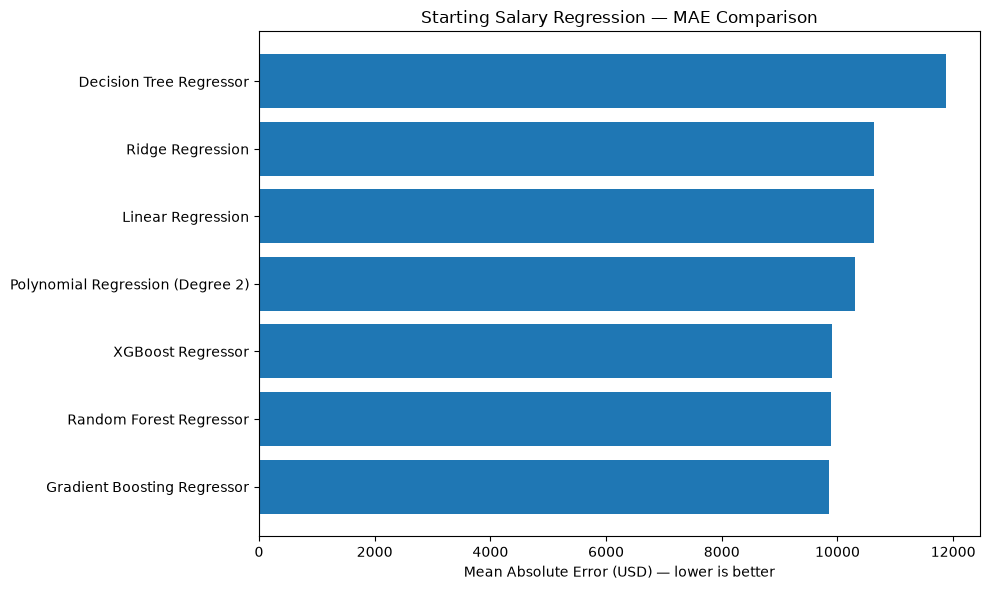

BEST SALARY MODEL BY MAE


,Model,MAE,RMSE,R2,Train_Time_sec
0,Gradient Boosting Regressor,9852.777263,11402.512595,0.286774,11.872407


In [67]:
plot_salary = salary_results_df.sort_values('MAE', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_salary['Model'], plot_salary['MAE'])
plt.xlabel('Mean Absolute Error (USD) — lower is better')
plt.title('Starting Salary Regression — MAE Comparison')
plt.tight_layout()
plt.show()

best_salary_name = salary_results_df.iloc[0]['Model']
best_salary_row = salary_results_df.iloc[0]

print('BEST SALARY MODEL BY MAE')
print('=' * 50)
display(best_salary_row.to_frame().T)

## 27. Actual vs predicted salary

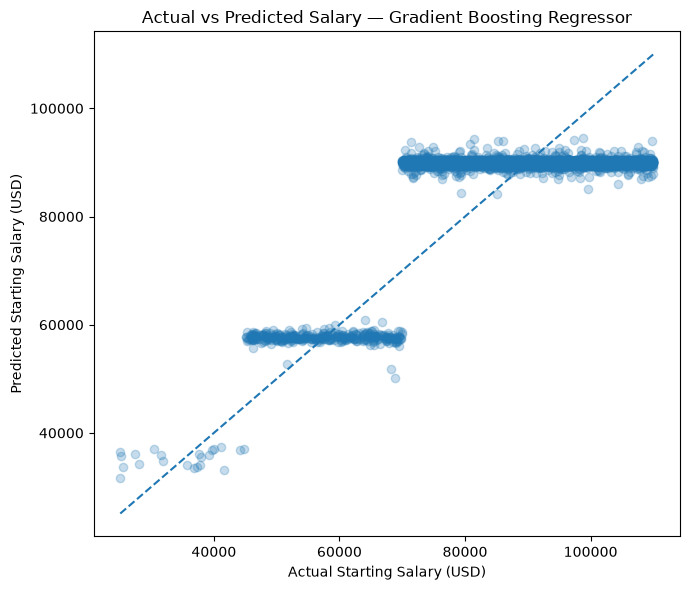

In [68]:
best_salary_pred = salary_predictions[best_salary_name]

plt.figure(figsize=(7, 6))
plt.scatter(y_salary_test, best_salary_pred, alpha=0.25)
low = min(y_salary_test.min(), best_salary_pred.min())
high = max(y_salary_test.max(), best_salary_pred.max())
plt.plot([low, high], [low, high], linestyle='--')
plt.xlabel('Actual Starting Salary (USD)')
plt.ylabel('Predicted Starting Salary (USD)')
plt.title(f'Actual vs Predicted Salary — {best_salary_name}')
plt.tight_layout()
plt.show()

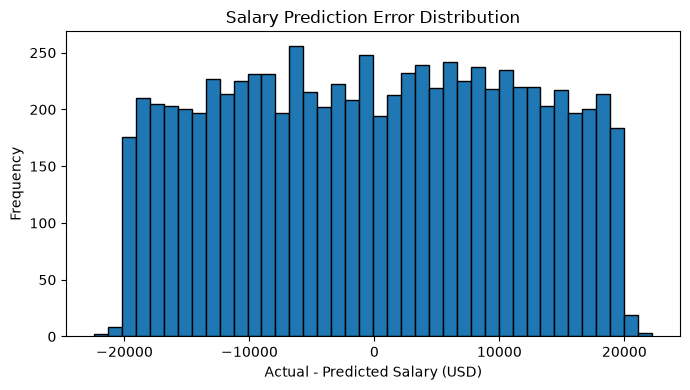

In [69]:
errors = y_salary_test.to_numpy() - best_salary_pred
plt.figure(figsize=(7, 4))
plt.hist(errors, bins=40, edgecolor='black')
plt.xlabel('Actual - Predicted Salary (USD)')
plt.ylabel('Frequency')
plt.title('Salary Prediction Error Distribution')
plt.tight_layout()
plt.show()

## 28. Save the best salary model

In [71]:
if best_salary_name == 'Polynomial Regression (Degree 2)':
    best_salary_pipeline = Pipeline([
        ('preprocessor', clone(salary_poly_preprocessor)),
        ('model', LinearRegression())
    ])
else:
    salary_estimator = clone(trained_salary_models[best_salary_name])
    best_salary_pipeline = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', salary_estimator)
    ])

best_salary_pipeline.fit(X_salary_train, y_salary_train)

joblib.dump(
    best_salary_pipeline,
    'best_starting_salary_pipeline.joblib'
)

salary_model_info = {
    'model_file': 'best_starting_salary_pipeline.joblib',
    'model_name': best_salary_name,
    'MAE_USD': float(best_salary_row['MAE']),
    'RMSE_USD': float(best_salary_row['RMSE']),
    'R2': float(best_salary_row['R2'])
}

with open('salary_model_info.json', 'w') as f:
    json.dump(salary_model_info, f, indent=2)

salary_results_df.to_csv('salary_regression_results.csv', index=False)

print(json.dumps(salary_model_info, indent=2))
print('Saved: best_starting_salary_pipeline.joblib')
print('Saved: salary_model_info.json')
print('Saved: salary_regression_results.csv')

{
  "model_file": "best_starting_salary_pipeline.joblib",
  "model_name": "Gradient Boosting Regressor",
  "MAE_USD": 9852.777262748163,
  "RMSE_USD": 11402.51259527945,
  "R2": 0.2867736481134654
}
Saved: best_starting_salary_pipeline.joblib
Saved: salary_model_info.json
Saved: salary_regression_results.csv


# Part V - Save the best model for Streamlit deployment

In [ ]:
winner=best['Model']
if winner=='Neural Network':
    nn_model.save('student_placement_nn.keras')
    joblib.dump(preprocessor,'nn_preprocessor.joblib')
    deployment={'type':'keras','model_file':'student_placement_nn.keras','preprocessor_file':'nn_preprocessor.joblib','positive_class':'Not Placed','metric':'F1_Macro'}
else:
    if winner in tuned_pipelines:
        deployment_pipeline=tuned_pipelines[winner]
    elif winner=='Logistic Regression + PCA':
        deployment_pipeline=pca_pipeline
    else:
        deployment_pipeline=Pipeline([('preprocessor',clone(preprocessor)),('model',clone(trained_models[winner]))])
        deployment_pipeline.fit(X_train,y_train)
    joblib.dump(deployment_pipeline,'best_student_placement_pipeline.joblib')
    deployment={'type':'sklearn','model_file':'best_student_placement_pipeline.joblib','positive_class':'Not Placed','metric':'F1_Macro'}
with open('deployment_choice.json','w') as f: json.dump(deployment,f,indent=2)
print(deployment)

{'type': 'sklearn', 'model_file': 'best_student_placement_pipeline.joblib', 'positive_class': 'Not Placed', 'metric': 'F1_Macro'}
